### Manuscript figures

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from sklearn.metrics import r2_score

from simulation_encoder.loaders.loader_retrieval import load_loaders
from simulation_encoder.models.model_retrieval import load_models
from notebook_utils.figure_helpers import (
    collect_spatial_mse_train_test,
    plot_figure2b_spatial_mse_bars,
    collect_timepoint_parity_data,
    plot_figure2c_timepoint_parity,
)

In [ ]:
# "gastruloid" | "arcade"
STUDY = "gastruloid"

CFG = {
    "gastruloid": {
        "study_dir": "architecture-gastruloid-32",
        "num_timepoints": 9,
        "dataset_name": "gastruloid_128",
    },
    "arcade": {
        "study_dir": "architecture-ARCADE",
        "num_timepoints": 15,
        "dataset_name": "vascular_function_128",
    },
}

image_dir = "data"
c = CFG[STUDY]
results_dir = f"results/{c['study_dir']}"
num_timepoints = c["num_timepoints"]
dataset_name = c["dataset_name"]

raw = load_models(
    results_dir,
    num_timepoints=num_timepoints,
    best_models_flag=True,
    map_location="cpu",
)
all_models = {
    k: v
    for k, v in sorted(raw.items())
}
loaders = load_loaders(results_dir, image_dir)
data_loaders = {
    name: {
        "train": ldr.get_dataloader("train"),
        "val": ldr.get_dataloader("val"),
        "test": ldr.get_dataloader("test"),
        "full": ldr,
    }
    for name, ldr in sorted(loaders.items())
}

print(STUDY, results_dir, list(all_models.keys()))


Loading model ae_small (1.96e+07 parameters)
Loading model cae_small (1.99e+07 parameters)
Loading model vit_small (2.03e+07 parameters)
Loading model neuralop_small (2.00e+07 parameters)
gastruloid results/architecture-gastruloid ['ae', 'cae', 'neuralop', 'vit']


### Figure 2

In [3]:
rows = collect_spatial_mse_train_test(
    results_dir,
    all_models,
    data_loaders,
    device="cpu"
)
for r in rows:
    print(
        f"{r['model']:12}  train(min)={r['train_mse']:.6f}  test={r['test_mse']:.6f}"
    )


Validation:   0%|                                                                           | 0/1845 [00:00<?, ?batch/s]/Users/jacobevarts/BagheriLab/simulation-encoder/.venv/lib/python3.11/site-packages/tltorch/factorized_tensors/factorized_tensors.py:66: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:351.)
  return self.__class__(self.tensor[indices])
/Users/jacobevarts/BagheriLab/simulation-encoder/.venv/lib/python3.11/site-packages/neuralop/layers/spectral_convolution.py:468: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x

ae            train(min)=0.011625  test=0.011986
cae           train(min)=0.010958  test=0.011744
neuralop      train(min)=0.010885  test=0.013729
vit           train(min)=0.011180  test=0.011519


Bar order (left → right): ae (gastruloid_128) | cae (gastruloid_128) | neuralop (gastruloid_128) | vit (gastruloid_128)


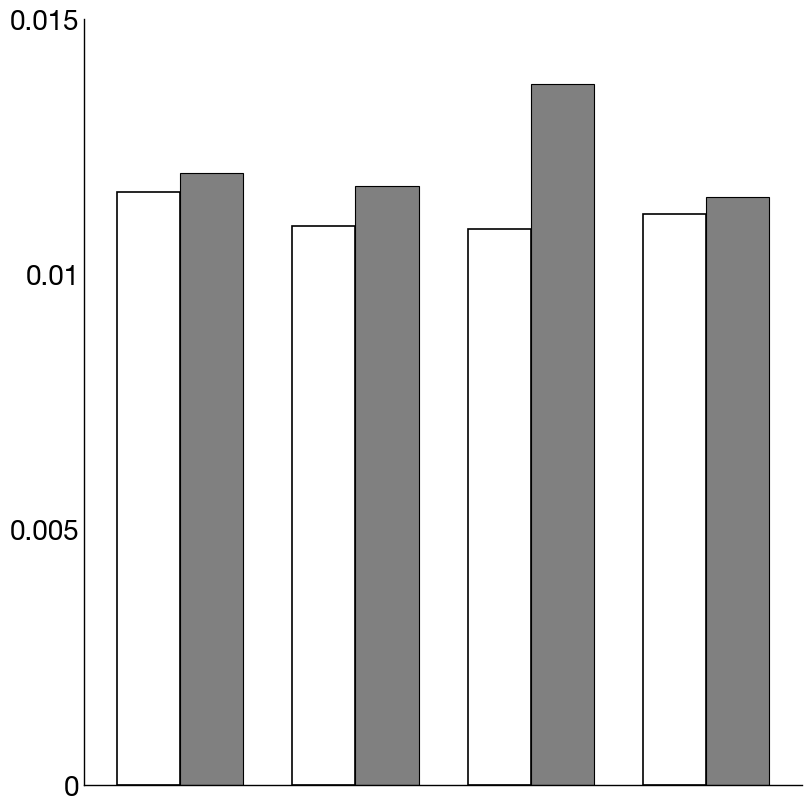

In [20]:
if STUDY == "gastruloid":
    yticks = [0.0, 0.005, 0.01, 0.015]
    ytick_labels = ["0", "0.005", "0.01", "0.015"]
else:
    yticks = None
    ytick_labels = None

fig = plot_figure2b_spatial_mse_bars(
    rows,
    yticks=yticks,
    ytick_labels=ytick_labels,
    save_path=f"figures/paper/figure2b_spatial_mse_{STUDY}.png",
)

ae r2=0.535
cae r2=0.794
neuralop r2=0.711
vit r2=0.587


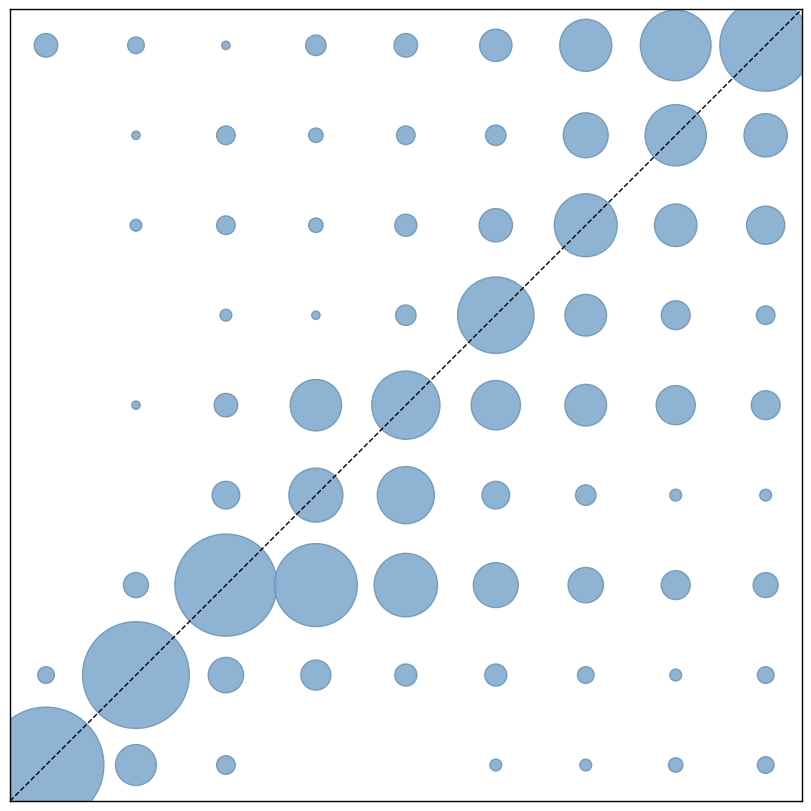

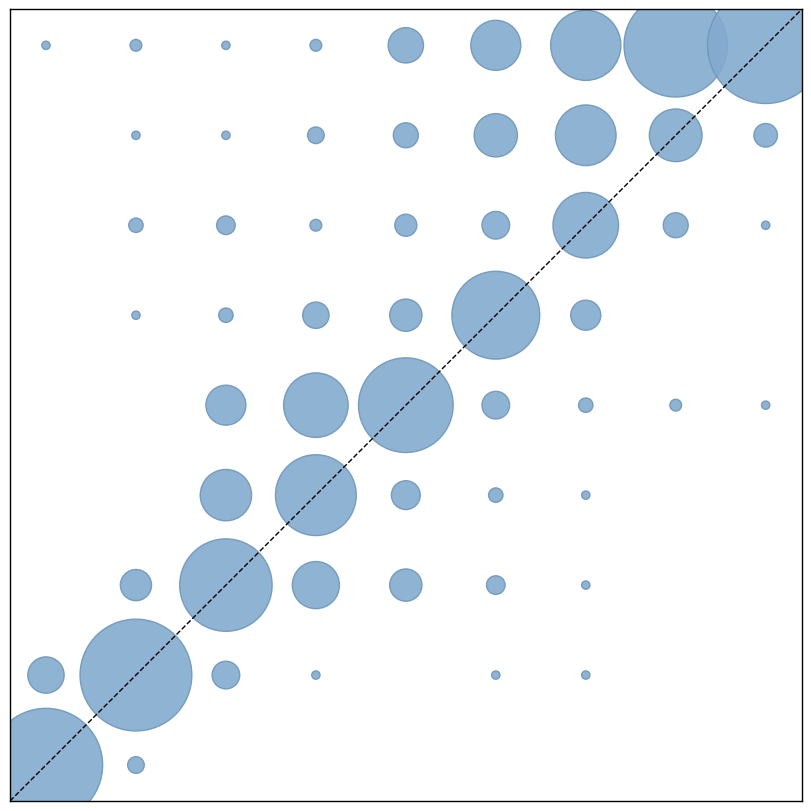

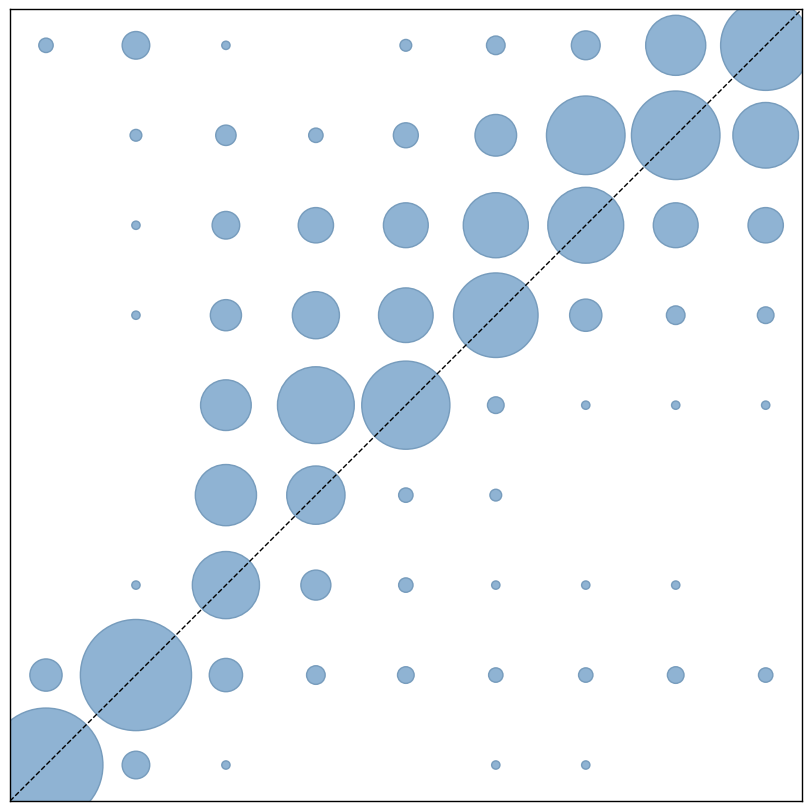

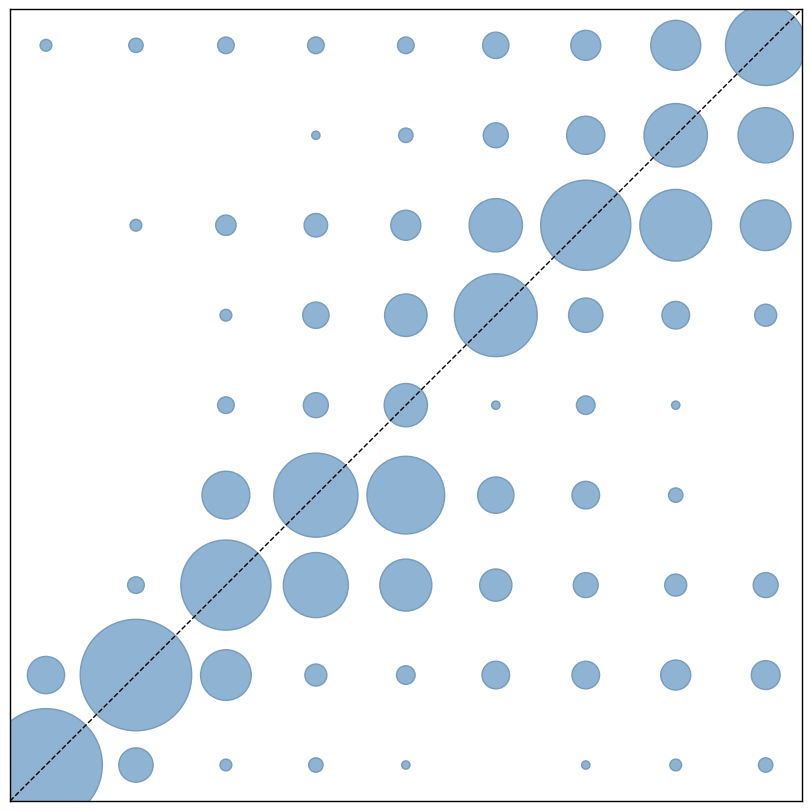

In [11]:
parity = collect_timepoint_parity_data(
    results_dir,
    all_models,
    split="test",
    device="cpu",
)

for model_name in sorted(parity.keys()):
    for dataset_name in sorted(parity[model_name].keys()):
        block = parity[model_name][dataset_name]
        y_true = block["true"]
        y_pred = block["pred"]
        print(f"{model_name} r2={r2_score(y_true, y_pred):.3f}")

        fig, ax = plot_figure2c_timepoint_parity(
            y_true,
            y_pred,
            save_path=f"figures/paper/figure2c_parity_{model_name}_{STUDY}.png",
        )


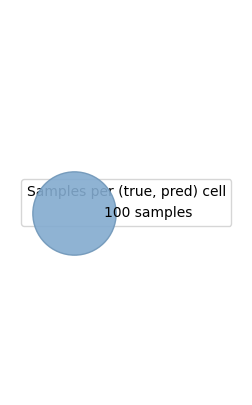

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Match `plot_figure2c_timepoint_parity` in notebook_utils/figure_helpers.py
PARITY_BASE_DOT = 36.0
PARITY_COUNT_POWER = 1.0
PARITY_FACE = "#83ABCF"
PARITY_EDGE = "#6F96B8"
PARITY_ALPHA = 0.9


def _parity_cell_counts(y_true, y_pred) -> np.ndarray:
    pairs = np.stack(
        [
            np.asarray(y_true, dtype=np.int64).ravel(),
            np.asarray(y_pred, dtype=np.int64).ravel(),
        ],
        axis=1,
    )
    _, counts = np.unique(pairs, axis=0, return_counts=True)
    return counts


def plot_parity_size_legend(
    legend_counts: list[int],
    *,
    base_dot_size: float = PARITY_BASE_DOT,
    count_size_power: float = PARITY_COUNT_POWER,
    save_path: str | None = None,
) -> plt.Figure:
    """Separate figure: circle size ↔ number of samples in one (true, pred) cell."""
    fig, ax = plt.subplots(figsize=(3.0, 5.0))
    ax.set_axis_off()
    for n in legend_counts:
        ax.scatter(
            [],
            [],
            s=base_dot_size * (float(n) ** count_size_power),
            c=PARITY_FACE,
            alpha=PARITY_ALPHA,
            edgecolors=PARITY_EDGE,
            linewidths=1.0,
            label=f"{n} samples",
        )
    ax.legend(
        scatterpoints=1,
        frameon=True,
        loc="center",
        title="Samples per (true, pred) cell",
        handletextpad=1.2,
        borderaxespad=0.5,
    )
    if save_path is not None:
        p = Path(save_path)
        p.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(p, dpi=300, bbox_inches="tight")
    return fig


max_cell_count = 0
for model_name in sorted(parity.keys()):
    for dataset_name in sorted(parity[model_name].keys()):
        block = parity[model_name][dataset_name]
        max_cell_count = max(max_cell_count, int(_parity_cell_counts(block["true"], block["pred"]).max()))

candidates = [100]
legend_counts = [c for c in candidates if c <= max_cell_count]
legend_counts = sorted(set(legend_counts))
if not legend_counts:
    legend_counts = [1]

fig_legend = plot_parity_size_legend(
    legend_counts,
    save_path=f"figures/paper/figure2c_parity_size_legend_{STUDY}.png",
)
